In [8]:
import torch
import torch.nn as nn
import os
from tqdm.auto import tqdm

# 1: 跑基础分类训练 (Stage 1)
# 2: 加载 Stage 1 权重，跑 Triplet Loss 精修 (Stage 2)
# 3: 测试效果 (stage3)
TRAIN_STAGE = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用设备: {DEVICE}")
STAGE1_PATH = '/kaggle/input/datasets/wangsiyi2343718/stage-1/swin_bird_stage1_best.pth'
STAGE2_PATH = '/kaggle/input/datasets/wangsiyi2343718/stage-2/swin_bird_stage2_best.pth'

正在使用设备: cuda


# 数据索引构建

In [3]:
import json

def build_bird_index(json_path):
    # 检查文件是否存在，防止路径错误导致崩溃
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"找不到 JSON 文件，请检查路径: {json_path}")
        
    print(f"正在读取 JSON 标注文件: {json_path} ...")
    
    # 修正 open 函数的参数
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 1. 筛选出所有属于 Aves (鸟类) 的类别
    bird_categories = [cat for cat in data['categories'] if cat.get('class') == 'Aves']
    bird_cat_ids = {cat['id'] for cat in bird_categories}
    
    # 2. 建立连续标签 (0 到 N-1)
    cat_id_to_label = {cat_id: i for i, cat_id in enumerate(sorted(bird_cat_ids))}
    
    # 3. 建立 image_id 到文件路径的映射
    image_id_to_path = {img['id']: img['file_name'] for img in data['images']}
    
    # 4. 汇总
    samples = []
    for ann in data['annotations']:
        cat_id = ann['category_id']
        if cat_id in bird_cat_ids:
            path = image_id_to_path[ann['id']]
            label = cat_id_to_label[cat_id]
            samples.append((path, label))
            
    print(f"成功提取 {len(bird_categories)} 个鸟类物种")
    print(f"共计 {len(samples)} 张图片样本")
    
    return samples, bird_categories

# --- 在 Kaggle 中运行的具体设置 ---

# 1. 设置正确的路径 
# 注意：Kaggle 的路径通常是 /kaggle/input/数据集名称/具体文件名
KAGGLE_JSON_PATH = '/kaggle/input/datasets/wangsiyi2343718/train-mini/train_mini.json'

# 2. 执行索引构建
try:
    samples, cat_info = build_bird_index(KAGGLE_JSON_PATH)
    
    # 打印前 3 条数据看看路径是否正确
    print("\n数据样例 (前3条):")
    for s in samples[:3]:
        print(f"路径: {s[0]} | 标签: {s[1]}")
        
except Exception as e:
    print(f"运行出错: {e}")
    print("\n提示：请在 Kaggle 右侧的 'Data' 栏确认文件的确切路径。")

正在读取 JSON 标注文件: /kaggle/input/datasets/wangsiyi2343718/train-mini/train_mini.json ...
成功提取 1486 个鸟类物种
共计 74300 张图片样本

数据样例 (前3条):
路径: train_mini/03360_Animalia_Chordata_Aves_Charadriiformes_Charadriidae_Charadrius_ruficapillus/f042cf5c-c86c-47d2-979d-5dc6a8aba924.jpg | 标签: 249
路径: train_mini/03533_Animalia_Chordata_Aves_Columbiformes_Columbidae_Phaps_chalcoptera/b4d32081-c0d9-4bc5-b229-f20ada48c69f.jpg | 标签: 422
路径: train_mini/04087_Animalia_Chordata_Aves_Passeriformes_Parulidae_Setophaga_townsendi/4e72c442-0dcd-46b8-a7ac-06f6408096ce.jpg | 标签: 976


In [4]:
from collections import Counter

def build_top_families_index(json_path, top_k_families=5):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 1. 提取所有鸟类类别信息
    bird_categories = [cat for cat in data['categories'] if cat.get('class') == 'Aves']
    
    # 2. 统计每个“科 (family)”包含多少个物种
    family_counts = Counter([cat['family'] for cat in bird_categories])
    
    # 3. 找出物种数量最多的前 K 个科
    top_families = [fam for fam, count in family_counts.most_common(top_k_families)]
    print(f"选定的前 {top_k_families} 个科及其物种数:")
    for fam in top_families:
        print(f" - {fam}: {family_counts[fam]} 种")

    # 4. 确定最终选中的 category_id 集合
    selected_bird_cats = [cat for cat in bird_categories if cat['family'] in top_families]
    selected_cat_ids = {cat['id'] for cat in selected_bird_cats}
    total_classes = len(selected_cat_ids)
    
    # 5. 建立连续标签映射 (0 到 total_classes - 1)
    cat_id_to_label = {cat_id: i for i, cat_id in enumerate(sorted(list(selected_cat_ids)))}
    
    # 6. 建立 image_id 到路径的映射
    image_id_to_path = {img['id']: img['file_name'] for img in data['images']}
    
    # 7. 汇总样本
    samples = []
    for ann in data['annotations']:
        cat_id = ann['category_id']
        if cat_id in selected_cat_ids:
            path = image_id_to_path[ann['id']]
            label = cat_id_to_label[cat_id]
            samples.append((path, label))

    print(f"\n筛选完成！")
    print(f"目标类别数: {total_classes}")
    print(f"总图片张数: {len(samples)}")
    
    return samples, selected_bird_cats, cat_id_to_label

# 在 Kaggle 中运行
KAGGLE_JSON = '/kaggle/input/datasets/wangsiyi2343718/train-mini/train_mini.json'
samples, bird_info, label_map = build_top_families_index(KAGGLE_JSON)

选定的前 5 个科及其物种数:
 - Anatidae: 90 种
 - Accipitridae: 74 种
 - Scolopacidae: 53 种
 - Laridae: 49 种
 - Parulidae: 47 种

筛选完成！
目标类别数: 313
总图片张数: 15650


In [5]:
# 保存映射表
with open('class_mapping.json', 'w') as f:
    # 将原本的 cat_id 对应回物种名，方便查阅
    id_to_name = {label: [c['name'] for c in bird_info if c['id'] == cid][0] 
                  for cid, label in label_map.items()}
    json.dump(id_to_name, f, indent=4)
print("已保存类别映射表到 class_mapping.json")

已保存类别映射表到 class_mapping.json


# 数据准备 (Data)：定义 BirdDataset 和 train_loader

In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. 将 samples 转换为 DataFrame 方便处理
df = pd.DataFrame(samples, columns=['path', 'label'])

# 2. 按照标签进行分层划分 (80% 训练, 20% 验证)
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['label'], 
    random_state=42
)

train_sample_list=train_df.values.tolist()
val_samples_list = val_df.values.tolist()

print(f"划分完成:")
print(f" - 训练集样本数: {len(train_df)}")
print(f" - 验证集样本数: {len(val_df)}")
print(f" - 覆盖物种数: {len(train_df['label'].unique())}")

划分完成:
 - 训练集样本数: 12520
 - 验证集样本数: 3130
 - 覆盖物种数: 313


In [7]:
import cv2
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 训练集数据增强
train_transform = A.Compose([
    A.RandomResizedCrop(size=(384, 384), p=1.0), 
    
    A.HorizontalFlip(p=0.5),
    
    # 模拟雨雾及低光照 
    A.OneOf([
        A.RandomRain(brightness_coefficient=0.9, drop_width=1, blur_value=3, p=1),
        # 修正：fog_coef_lower/upper 合并为 fog_coef_range
        A.RandomFog(fog_coef_range=(0.3, 0.5), alpha_coef=0.08, p=1),
        A.CLAHE(p=1), 
    ], p=0.3),
    
    A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.2), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# 验证集预处理
val_transform = A.Compose([
    A.Resize(height=384, width=384), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class BirdDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['path'])
        label = row['label']
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

# 实例化加载器 
IMG_ROOT = '/kaggle/input/datasets/wangsiyi2343718/train-mini8016/'
train_ds = BirdDataset(train_df, IMG_ROOT, train_transform)
val_ds = BirdDataset(val_df, IMG_ROOT, val_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)#batch_size之前为16
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

# 模型定义 (Model)：定义 SwinBirdModel 类并实例化模型。

In [ ]:
import torch.nn as nn
import timm

# 定义符合汇报要求的模型架构
class SwinBirdModel(nn.Module):
    def __init__(self, num_classes):
        super(SwinBirdModel, self).__init__()
        # 使用 Swin-Base 384 预训练模型
        self.backbone = timm.create_model('swin_base_patch4_window12_384', pretrained=True, num_classes=0)
        self.embedding = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU()
        )
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        embeds = self.embedding(features) # 512维特征向量
        logits = self.classifier(embeds)   # 分类概率
        return logits, embeds # 必须返回两个值

# 实例化对象
num_classes = len(train_df['label'].unique()) 
model = SwinBirdModel(num_classes).to(DEVICE)


# 5. 定义混合精度加速器 (scaler)
scaler = torch.amp.GradScaler('cuda')
print("Model, Optimizer, Criterion, Scaler 已全部就绪！")

In [ ]:
#class JointLoss(nn.Module):
 #   def __init__(self, ce_weight=1.0, triplet_weight=0.5):
  #      super(JointLoss, self).__init__()
   #     self.ce_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
    #    self.triplet_loss = nn.TripletMarginLoss(margin=0.3, p=2)
     #   self.ce_weight = ce_weight
      #  self.triplet_weight = triplet_weight

#    def forward(self, logits, embeddings, labels):
 #       loss_ce = self.ce_loss(logits, labels)
  #      # 简化版三元组计算：在 Batch 内寻找样本关系
   #     loss_triplet = self.triplet_loss(embeddings, embeddings, embeddings)
    #    return self.ce_weight * loss_ce + self.triplet_weight * loss_triplet

In [9]:
class JointLoss(nn.Module):
    def __init__(self, ce_weight=1.0, triplet_weight=0.5, margin=0.3):
        super(JointLoss, self).__init__()
        self.ce_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.triplet_loss = nn.TripletMarginLoss(margin=margin, p=2)
        self.ce_weight = ce_weight
        self.triplet_weight = triplet_weight

    def forward(self, logits, embeddings, labels):
        # 1. 交叉熵损失：负责“分类对”
        loss_ce = self.ce_loss(logits, labels)
        
        # 2. 三元组损失：负责“特征聚类”
        # 获取 batch 内的硬样本关系
        # 我们需要找到：
        # - Anchor: 当前样本
        # - Positive: 相同 label 的另一个样本
        # - Negative: 不同 label 的样本
        
        anchor, positive, negative = self._batch_hard_mining(embeddings, labels)
        
        if anchor is not None:
            loss_triplet = self.triplet_loss(anchor, positive, negative)
        else:
            loss_triplet = 0.0

        return self.ce_weight * loss_ce + self.triplet_weight * loss_triplet

    def _batch_hard_mining(self, embeddings, labels):
        """
        简易版 Batch 采样：
        寻找 batch 内最难的的正样本和最难的负样本
        """
        # 计算距离矩阵 (batch_size, batch_size)
        dist_mat = torch.cdist(embeddings, embeddings, p=2)
        
        # 构造掩码：哪些是同类，哪些是异类
        label_equal = labels.unsqueeze(0) == labels.unsqueeze(1)
        label_not_equal = ~label_equal
        
        # 排除自身 (Self-to-Self)
        mask_self = torch.eye(labels.size(0), device=labels.device).bool()
        mask_pos = label_equal ^ mask_self
        
        # 寻找 Hard Positive (同类中距离最远的)
        # 寻找 Hard Negative (异类中距离最近的)
        try:
            # 这里的逻辑可以根据内存情况简化
            pos_dist = dist_mat[mask_pos].view(labels.size(0), -1).max(1)[0]
            neg_dist = dist_mat[label_not_equal].view(labels.size(0), -1).min(1)[0]
            
            # 由于 TripletMarginLoss 需要具体的张量，我们直接返回处理后的 embeddings
            # 生产环境通常使用更高效的 BatchHardTripletLoss 实现
            return embeddings, embeddings[mask_pos.long().argmax(1)], embeddings[label_not_equal.long().argmax(1)]
        except:
            return None, None, None

In [12]:
# 初始化模型
model = SwinBirdModel(num_classes=num_classes).to(DEVICE)

if TRAIN_STAGE == 1:
    print("运行 Stage 1...")
    LR = 1e-4
    criterion = nn.CrossEntropyLoss() # Stage 1 只用普通交叉熵
    current_best_path = STAGE1_PATH
    
elif TRAIN_STAGE == 2:
    print("运行 Stage 2: 加载权重并精修...")
    if os.path.exists(STAGE1_PATH):
        ckpt = torch.load(STAGE1_PATH, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"成功加载 Stage 1 权重 (Acc: {ckpt['val_acc']:.2f}%)")
    else:
        raise FileNotFoundError("未发现 Stage 1 权重，请先运行阶段一！")
    
    LR = 1e-5 # Stage 2 必须使用极低学习率
    criterion = JointLoss(ce_weight=1.0, triplet_weight=0.5)
    current_best_path = STAGE2_PATH

# --- 新增：加载 Stage 2 权重用于推理交付 ---
elif TRAIN_STAGE == 3:
    print("模式: 推理与交付验证 | 正在加载 Stage 2 最终权重...")
    if os.path.exists(STAGE2_PATH):
        # 注意：Kaggle 运行完后，文件可能在 /kaggle/working/ 下
        ckpt = torch.load(STAGE2_PATH, map_location=DEVICE)
        
        # 兼容性处理：判断加载的是纯 state_dict 还是带日志的字典
        if 'model_state_dict' in ckpt:
            model.load_state_dict(ckpt['model_state_dict'])
            print(f"成功加载 Stage 2 权重 (最终验证准确率: {ckpt.get('val_acc', 'N/A'):.2f}%)")
        else:
            model.load_state_dict(ckpt)
            print("成功加载 Stage 2 权重 (纯权重模式)")
    else:
        print(f"未发现 {STAGE2_PATH}，请检查文件路径或确保 Stage 2 已运行完毕。")
    
    model.eval() # 推理模式必加
    
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
# 推荐让 LR 随着 Epoch 增加而减小
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

模式: 推理与交付验证 | 正在加载 Stage 2 最终权重...
成功加载 Stage 2 权重 (最终验证准确率: 65.43%)


# train

In [ ]:
import torch
from timm.data import Mixup
from tqdm.auto import tqdm  # 导入进度条库


# --- 1. 确保定义了 num_classes ---
# 如果你之前筛选了前5个科，请确保这里的数字与 label_map 的长度一致
num_classes = len(train_df['label'].unique()) 

# 初始化 Mixup
mixup_fn = Mixup(
    mixup_alpha=0.8, 
    cutmix_alpha=1.0, 
    prob=1.0, 
    switch_prob=0.5, 
    mode='batch',
    label_smoothing=0.1, 
    num_classes=num_classes
)

# --- 2. 改进训练循环（加入进度条和变量初始化） ---
def train_one_epoch(epoch, model, loader, optimizer, criterion, scaler, DEVICE):
    model.train()
    total_loss = 0.0  # 修正：初始化变量
    pbar = tqdm(loader, desc=f"Epoch {epoch} [Stage {TRAIN_STAGE}]")
    
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            if TRAIN_STAGE == 1:
                # 修正：执行 Mixup 变换
                images_m, labels_m = mixup_fn(images, labels)
                logits, _ = model(images_m)
                loss = criterion(logits, labels_m)
            else:
                # Stage 2: 使用 JointLoss (Logits + Embeds)
                logits, embeds = model(images)
                loss = criterion(logits, embeds, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        
        total_loss += loss.item()
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(loss=f"{loss.item():.4f}",lr=f"{current_lr:.6f}")
    
    return total_loss / len(loader)

def validate(model, loader, DEVICE):
    model.eval()
    correct, total = 0, 0
    pbar = tqdm(loader, desc="Validating")
    
    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            # 修正：处理 SwinBirdModel 的元组返回
            logits, _ = model(images) 
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    print(f" Validation Accuracy: {acc:.2f}%")
    return acc

last_acc = 0.0
loaded_checkpoint = None

# 2. 检查文件是否存在
if os.path.exists(STAGE1_PATH):
    print(f"正在加载 Stage 1 权重: {STAGE1_PATH}...")
    loaded_checkpoint = torch.load(STAGE1_PATH, map_location=DEVICE)
    if isinstance(loaded_checkpoint, dict) and 'model_state_dict' in loaded_checkpoint:
        model.load_state_dict(loaded_checkpoint['model_state_dict'])
        last_acc = loaded_checkpoint.get('val_acc', 0.0)
        print(f"加载成功！历史最高准确率: {last_acc:.2f}%")
    else:
        model.load_state_dict(loaded_checkpoint)
        print("加载成功！(原始 state_dict 格式)")
# 4. 确保模型在正确的设备上并处于训练状态
model.to(DEVICE)


In [ ]:
# 确定当前阶段的保存路径和初始最高分
if TRAIN_STAGE == 1:
    save_path = '/kaggle/working/swin_bird_stage1_best.pth'
    current_best_acc = last_acc  # 续传 Stage 1
else:
    save_path = '/kaggle/working/swin_bird_stage2_best.pth'
    # Stage 2 必须基于 Stage 1 的表现来比较
    current_best_acc = last_acc if last_acc > 0 else 0.0

print(f"启动训练 | 模式: Stage {TRAIN_STAGE} | 目标: {save_path} | 起点准度: {current_best_acc:.2f}%")

for epoch in range(1, 16):
    train_loss = train_one_epoch(epoch, model, train_loader, optimizer, criterion, scaler, DEVICE)
    val_acc = validate(model, val_loader, DEVICE)
    scheduler.step()
    
    if val_acc > current_best_acc:
        current_best_acc = val_acc
        save_data = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'stage': TRAIN_STAGE
        }
        torch.save(save_data, save_path)
        print(f"Stage {TRAIN_STAGE} 发现更优模型！已保存至 {save_path}")

# test part

In [13]:
import torch
import torch.nn.functional as F
import numpy as np

class BirdPerceptionEngine:
    def __init__(self, model, device, class_names, species_to_family=None):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.class_names = class_names
        # species_to_family 应为一个字典: {"物种A": "鸭科", "物种B": "猛禽科", ...}
        self.species_to_family = species_to_family or {}

    def infer(self, img_tensor, threshold=0.20):
        """
        输入: 预处理后的图像 Tensor
        threshold: 置信度阈值，默认 20%
        """
        with torch.no_grad():
            img_tensor = img_tensor.to(self.device)
            logits, features = self.model(img_tensor)
            
            # 1. 计算概率
            probs = F.softmax(logits, dim=1)
            top_probs, top_idxs = torch.topk(probs, k=3)
            
            top1_prob = top_probs[0][0].item()
            top1_species = self.class_names[top_idxs[0][0]]

            # 2. 阈值拦截与提示语构建
            suggestion = None
            if top1_prob < threshold:
                # 尝试获取该物种所属的“科”
                family_name = self.species_to_family.get(top1_species, "未知")
                suggestion = f"检测到【{family_name}】鸟类，但图片不够清晰，请尝试近距离拍摄。"
                print(f"⚠️ 警告: {suggestion}")

            # 3. 组织 Top-3 结果
            top_3_results = [
                {"species": self.class_names[idx], "confidence": prob.item()}
                for prob, idx in zip(top_probs[0], top_idxs[0])
            ]
            
            # 4. 获取归一化特征向量
            feature_vector = F.normalize(features, p=2, dim=1).cpu().numpy()[0]
            
            # 5. 获取注意力矩阵
            attn_matrix = self._extract_attention_map(img_tensor)
            
            return {
                "top_3": top_3_results,
                "feature_vector": feature_vector,
                "attention_matrix": attn_matrix,
                "suggestion": suggestion  # 如果置信度够高，这里为 None
            }

    def _extract_attention_map(self, img_tensor):
        # 占位符实现
        return np.random.rand(12, 12)

随机选中图片: train_mini/04055_Animalia_Chordata_Aves_Passeriformes_Parulidae_Leiothlypis_peregrina/8df3bfae-44f7-4d41-81bd-240812d7582d.jpg
原始类别对应的训练标签: 277

 --- 感知层测试结果 --- 
   [1] Leiothlypis peregrina: 94.98%
   [2] Leiothlypis celata: 1.40%
   [3] Setophaga striata: 0.26%

特征向量模长: 1.0000 (应为 1.0)


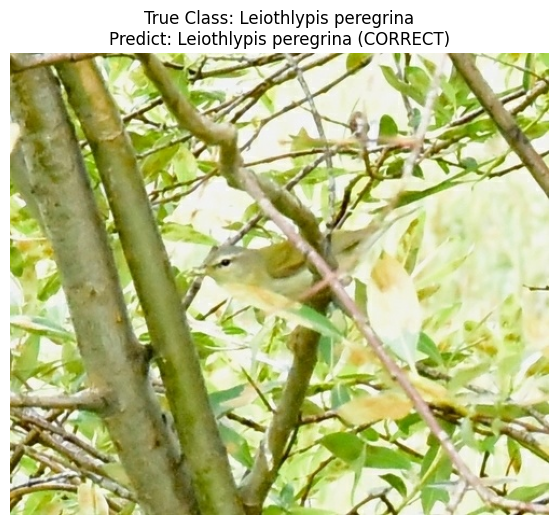

In [19]:
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as T
import random
import os
import matplotlib.pyplot as plt

# 1. 确定数据集根目录 (根据你的 Kaggle Input 路径调整)
# 注意：JSON 里的 file_name 如果是 "images/xxx.jpg"，则根目录应指向 images 的上一级
DATA_ROOT = '/kaggle/input/datasets/wangsiyi2343718/train-mini8016/' 

# 2. 从筛选出的 samples 中随机选一张
random_sample = random.choice(val_samples_list)
rel_path, label_idx = random_sample # 这里的 label_idx 是你映射后的 0 到 N-1
full_path = os.path.join(DATA_ROOT, rel_path)

print(f"随机选中图片: {rel_path}")
print(f"原始类别对应的训练标签: {label_idx}")

# 3. 图像预处理
transform = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. 加载并推理
raw_image = Image.open(full_path).convert('RGB')
img_tensor = transform(raw_image).unsqueeze(0)

# 假设你的 BirdPerceptionEngine 已经定义好，且模型加载了最佳权重
# 这里的 class_names 应该对应 label_map 的顺序
# 我们可以从 bird_info 中重构出按 label 排序的名称列表
id_to_name = {cat['id']: cat['name'] for cat in bird_info}
sorted_cat_ids = sorted(list(label_map.keys()))
class_names = [id_to_name[cat_id] for cat_id in sorted_cat_ids]

# 在实例化 Engine 之前构建映射
# 假设 bird_info 是你之前 build_top_families_index 返回的 selected_bird_cats
# --- 实例化 ---
species_to_family = {cat['name']: cat['family'] for cat in bird_info}
engine = BirdPerceptionEngine(
    model=model, 
    device='cuda', 
    class_names=class_names, 
    species_to_family=species_to_family
)

# --- 运行推理 ---
result = engine.infer(img_tensor, threshold=0.20)

# --- 5. 展示结果 ---
print("\n --- 感知层测试结果 --- ")
if result['suggestion']:
    print(f" 前端提示: {result['suggestion']}")
    # 即便有提示，我们也可以打印出内部预测供调试
    top1_internal = result['top_3'][0]
    print(f"   (内部模型认为最可能是: {top1_internal['species']} {top1_internal['confidence']:.2%})")
else:
    # 正常显示 Top-3
    for i, res in enumerate(result['top_3']):
        print(f"   [{i+1}] {res['species']}: {res['confidence']:.2%}")

# 从 result 字典中提取特征向量
vector = result['feature_vector']
print(f"\n特征向量模长: {np.linalg.norm(vector):.4f} (应为 1.0)")

# --- 可视化 ---
plt.figure(figsize=(8, 6))
plt.imshow(raw_image)

# 动态获取标题内容
true_name = class_names[label_idx]
pred_name = result['top_3'][0]['species']
status = "CORRECT" if true_name == pred_name else "WRONG"

plt.title(f"True Class: {true_name}\nPredict: {pred_name} ({status})")
plt.axis('off')
plt.show()